# 08 — Baseline MLP with training-only epoch selection

This notebook keeps the frozen Morgan fingerprints, pKi targets, and outer random/scaffold splits. For each protocol, it partitions **only outer training rows** into an internal fit and stopping set. Five fixed initialization seeds each select an epoch from internal stopping MSE, then start a fresh model and train on **all outer training rows** for that many epochs. Outer validation is read only after these choices. No test labels, predictions, or cliff pairs are used.

This corrects the earlier validation-selected baseline. The archived notebook has been removed; the prior validation use remains a limitation. The corrected outer scores are **development-validation** results because earlier work already inspected those labels. Final claims require the reserved test sets after model choices are fixed.

**Reference:** All source and supporting files are in [provenance](../provenance/README.md). The data provenance [Excel workbook](../provenance/CB2_data_provenance.xlsx) is generated from the current data and refreshed by each notebook's final cell. Saved outputs below describe the previous execution; printed old paths can differ. Rerun notebooks 00–10 in order to refresh the complete pipeline.

**MLP overview:** Open [summary.xlsx](../provenance/models/multilayer_perceptron/summary.xlsx) for baseline and tuned results and training details, or the adjacent `baseline/` folder for this notebook's original evidence. A successful execution replaces this variant's current result and regenerates the combined workbook.
Replacing the baseline also clears the dependent tuned result; run notebook 09 next.


## 1. Verify the frozen preparation handoff

Read the same hashed preparation arrays and split labels used by the forest, XGBoost, and SVR notebooks. Structure keys align all reports; row position in a CSV is never assumed to match an array.


In [1]:
from pathlib import Path
import sys
# Shared storage helpers keep the notebooks on the same completed dataset.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
from provenance_support import (
    latest_acquisition, current_selection, current_curation, current_preparation,
    current_mlp_baseline, save_review_record, load_review_record,
)
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import platform

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import sklearn
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from rdkit import DataStructs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PREP_MANIFEST_REL = current_preparation(project_root)
MLP_NAMES = {"random": "random_mlp", "scaffold": "scaffold_mlp"}
SUBSETS = ("train", "validation", "test")
run_started_at_utc = datetime.now(timezone.utc).isoformat()
# Accept running from the repository root or its notebooks folder.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "notebooks/03_modeling_preparation.ipynb").is_file()

def sha256_file(path):
    """Read bytes in chunks to verify recorded source and output files."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# The named run must be complete and must have passed every recorded preparation check.
prep_manifest_path = project_root / PREP_MANIFEST_REL
assert prep_manifest_path.is_file(), f"Preparation manifest is missing: {prep_manifest_path}"
with prep_manifest_path.open(encoding="utf-8") as stream:
    prep_manifest = json.load(stream)
assert prep_manifest.get("completed_at_utc") and prep_manifest.get("stage") == "modeling_preparation"
required_checks = (
    "source_hashes", "saved_arrays_and_fingerprint_bits", "saved_splits_and_scaffolds",
    "saved_audit_reports",
)
for check in required_checks:
    assert prep_manifest.get("verification", {}).get(check) is True, check
assert prep_manifest.get("models_fitted") is False
prep_folder_rel = Path(prep_manifest["output_folder"])
assert (project_root / prep_folder_rel).resolve() == prep_manifest_path.parent.resolve()
# Only the frozen array, split, and similarity files enter this baseline.
required_filenames = (
    "fingerprints_and_targets.npz", "split_assignments.csv", "heldout_training_neighbors.csv",
)
artifact_paths = {}
for filename in required_filenames:
    relative_name = (prep_folder_rel / filename).as_posix()
    assert relative_name in prep_manifest["artifact_sha256"], filename
    artifact_path = project_root / relative_name
    assert artifact_path.is_file(), f"Preparation artifact is missing: {relative_name}"
    assert sha256_file(artifact_path) == prep_manifest["artifact_sha256"][relative_name], relative_name
    artifact_paths[filename] = artifact_path
source_manifest_hash = sha256_file(prep_manifest_path)

# Exact package versions avoid changing fingerprint interpretation or estimator behavior silently.
# The operating system is recorded too: tree libraries can resolve near-tied splits
# differently on Windows and Linux, so results are only exactly comparable on one OS.
installed_versions = {
    "python": platform.python_version(), "platform": platform.system(), "rdkit": rdkit.__version__,
    "numpy": np.__version__, "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "joblib": joblib.__version__,
}
# A version mismatch could change fingerprint or estimator behavior between runs.
version_differences = {
    package: (saved, installed_versions.get(package))
    for package, saved in prep_manifest["software_versions"].items()
    if installed_versions.get(package) != saved
}
assert not version_differences, f"Preparation/current software versions differ: {version_differences}"
print(f"{'Preparation run':<27} | {PREP_MANIFEST_REL.as_posix()}")
print(f"{'Verified input artifacts':<27} | {len(artifact_paths):>7,}")
print(f"{'scikit-learn version':<27} | {sklearn.__version__}")

Preparation run             | provenance/preparation/manifest.json
Verified input artifacts    |       3
scikit-learn version        | 1.9.0


## 2. Reuse the outer random and scaffold assignments

The 2,048 Morgan bits are converted from integer 0/1 to float 0/1 for scikit-learn. This changes storage type only; no fingerprints, pKi targets, or outer split memberships change.


In [2]:
# NPZ loading disallows pickled objects and preserves the preparation row order.
with np.load(artifact_paths["fingerprints_and_targets.npz"], allow_pickle=False) as saved:
    X = saved["X"]
    y = saved["y"]
    structure_keys = saved["rdkit_smiles"]
feature_width = int(prep_manifest["configuration"]["fingerprint"]["bits"])
assert X.ndim == 2 and X.shape[1] == feature_width
assert X.dtype == np.uint8 and np.isin(X, (0, 1)).all()
assert y.ndim == 1 and len(X) == len(y) == len(structure_keys)
assert np.isfinite(y).all() and structure_keys.dtype.kind == "U"
assert len(set(structure_keys)) == len(structure_keys) == prep_manifest["counts"]["structures"]

# scikit-learn's network expects floating-point input; this preserves every binary bit.
X_float = X.astype(np.float32)
np.testing.assert_array_equal(X_float, X)

# Map saved labels through structure keys rather than relying on CSV row position.
assignments = pd.read_csv(artifact_paths["split_assignments.csv"], dtype=str, keep_default_na=False)
assert list(assignments.columns) == [
    "split_strategy", "rdkit_smiles", "subset", "scaffold", "fingerprint_group_id"
]
assert len(assignments) == len(structure_keys) * len(MLP_NAMES)
assert not assignments.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert set(assignments["split_strategy"]) == set(MLP_NAMES)
assert set(assignments["subset"]) == set(SUBSETS)
# Translate saved structure labels into array positions without shuffling rows.
split_indices = {}
for strategy in MLP_NAMES:
    rows = assignments.loc[assignments["split_strategy"].eq(strategy)]
    assert set(rows["rdkit_smiles"]) == set(structure_keys)
    subset_by_key = dict(zip(rows["rdkit_smiles"], rows["subset"]))
    labels = np.asarray([subset_by_key[key] for key in structure_keys])
    split_indices[strategy] = {}
    for subset in SUBSETS:
        indices = np.flatnonzero(labels == subset)
        expected = prep_manifest["counts"]["split_subsets"][strategy][subset]["structures"]
        assert len(indices) == expected and len(indices) > 0
        assert set(structure_keys[indices]) == set(rows.loc[rows["subset"].eq(subset), "rdkit_smiles"])
        split_indices[strategy][subset] = indices
# Disjointness protects the held-out labels from entering training updates.
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["validation"])
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["test"])
    assert set(split_indices[strategy]["validation"]).isdisjoint(split_indices[strategy]["test"])
    print(f"{strategy:<10} | train {len(split_indices[strategy]['train']):>5,} | "
          f"validation {len(split_indices[strategy]['validation']):>4,} | "
          f"reserved test {len(split_indices[strategy]['test']):>4,}")

random     | train 2,860 | validation  358 | reserved test  358
scaffold   | train 2,778 | validation  461 | reserved test  337


## 3. Freeze internal fit and stopping membership

Seed 2026 controls these internal partitions and is separate from the model initialization seeds. The random protocol follows the preparation notebook's row-level random policy. The scaffold protocol follows its `GroupShuffleSplit` policy, keeping each saved scaffold wholly on one side. Exact-fingerprint overlap is measured for both; the preparation did not require exact groups to remain together.


In [3]:
# Use only outer-training indices; validation and test never enter either splitter.
# Keep membership randomness separate from network initialization randomness.
internal_seed = 2026
internal_rows = []
internal_indices = {}
internal_diagnostics = {}
for strategy in MLP_NAMES:
    outer_train = split_indices[strategy]["train"]
    protocol_rows = assignments.loc[assignments["split_strategy"].eq(strategy)].set_index("rdkit_smiles")
    train_keys = structure_keys[outer_train]
    train_scaffolds = protocol_rows.loc[train_keys, "scaffold"].to_numpy()
    train_fp_groups = protocol_rows.loc[train_keys, "fingerprint_group_id"].to_numpy()
    # Match the frozen outer protocol: rows for random, whole scaffolds for scaffold.
    if strategy == "random":
        fit_local, stop_local = train_test_split(
            np.arange(len(outer_train)), test_size=0.20, random_state=internal_seed, shuffle=True
        )
        method = "train_test_split on outer-training molecular rows"
    else:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=internal_seed)
        fit_local, stop_local = next(splitter.split(outer_train, groups=train_scaffolds))
        method = "GroupShuffleSplit on saved outer-training scaffold labels"
    fit_indices, stop_indices = outer_train[fit_local], outer_train[stop_local]
    # Verify coverage and separation before any model can see these arrays.
    assert len(fit_indices) and len(stop_indices)
    assert set(fit_indices).isdisjoint(stop_indices)
    assert set(fit_indices) | set(stop_indices) == set(outer_train)
    assert set(fit_indices).isdisjoint(split_indices[strategy]["validation"])
    assert set(stop_indices).isdisjoint(split_indices[strategy]["test"])
    scaffold_overlap = len(set(train_scaffolds[fit_local]) & set(train_scaffolds[stop_local]))
    if strategy == "scaffold":
        assert scaffold_overlap == 0
    # Identical fingerprints can cross this internal boundary even without scaffold overlap.
    fingerprint_overlap = len(set(train_fp_groups[fit_local]) & set(train_fp_groups[stop_local]))
    internal_indices[strategy] = {"fit": fit_indices, "stopping": stop_indices}
    internal_diagnostics[strategy] = {
        "method": method, "split_seed": internal_seed, "fit_structures": len(fit_indices),
        "stopping_structures": len(stop_indices), "scaffold_group_overlap": scaffold_overlap,
        "exact_fingerprint_group_overlap": fingerprint_overlap,
    }
    for phase, indices in (("fit", fit_indices), ("stopping", stop_indices)):
        for index in indices:
            key = str(structure_keys[index])
            internal_rows.append({
                "split_strategy": strategy, "rdkit_smiles": key, "internal_subset": phase,
                "scaffold": protocol_rows.loc[key, "scaffold"],
                "fingerprint_group_id": protocol_rows.loc[key, "fingerprint_group_id"],
                "split_seed": internal_seed,
            })
    print(f"{strategy:<10} | fit {len(fit_indices):>5,} | stopping {len(stop_indices):>5,} | "
          f"scaffold overlap {scaffold_overlap:>3,} | exact-fingerprint overlap {fingerprint_overlap:>3,}")
internal_assignments = pd.DataFrame(internal_rows).sort_values(
    ["split_strategy", "internal_subset", "rdkit_smiles"]
).reset_index(drop=True)
assert not internal_assignments.duplicated(["split_strategy", "rdkit_smiles"]).any()


random     | fit 2,288 | stopping   572 | scaffold overlap 197 | exact-fingerprint overlap  28


scaffold   | fit 2,169 | stopping   609 | scaffold overlap   0 | exact-fingerprint overlap   6


## 4. Freeze exploratory activity-cliff pairs

No project-wide cliff rule was fixed in preparation, so this **provisional** analysis calls an unordered pair of distinct validation structures a cliff when binary fingerprint Tanimoto is at least 0.80 and absolute observed pKi difference is at least 1.0 (a tenfold Ki difference). Pairs are ordered by structure key, built once per outer-validation set, and never used to choose models. Exact-fingerprint pairs are flagged. Overlapping pairs are dependent evidence, not independent replicates.


In [4]:
# RDKit's binary Tanimoto uses the same saved 2,048 bits without regenerating molecules.
cliff_similarity = 0.80
cliff_pki_gap = 1.0
# Build one prediction-independent pair definition for every seed and model.
cliff_rows = []
cliff_participants = {}
for strategy in MLP_NAMES:
    validation_indices = split_indices[strategy]["validation"]
    ordered_indices = sorted(validation_indices, key=lambda index: str(structure_keys[index]))
    ordered_keys = [str(structure_keys[index]) for index in ordered_indices]
    bit_vectors = [DataStructs.CreateFromBitString(''.join(map(str, X[index])))
                   for index in ordered_indices]
    assert len(ordered_keys) == len(set(ordered_keys))
    participants = set()
    # Later endpoints only ensure each unordered pair appears once, with no self-pairs.
    for left_position in range(len(ordered_indices) - 1):
        similarities = DataStructs.BulkTanimotoSimilarity(
            bit_vectors[left_position], bit_vectors[left_position + 1:]
        )
        for offset, similarity in enumerate(similarities, start=left_position + 1):
            left_index, right_index = ordered_indices[left_position], ordered_indices[offset]
            observed_difference = float(y[left_index] - y[right_index])
            # Apply both declared thresholds before recording a stable ordered pair.
            if similarity >= cliff_similarity and abs(observed_difference) >= cliff_pki_gap:
                left_key, right_key = ordered_keys[left_position], ordered_keys[offset]
                assert left_key < right_key
                participants.update((left_key, right_key))
                cliff_rows.append({
                    "split_strategy": strategy, "left_rdkit_smiles": left_key,
                    "right_rdkit_smiles": right_key,
                    "tanimoto": float(similarity),
                    "left_observed_pki": float(y[left_index]),
                    "right_observed_pki": float(y[right_index]),
                    "observed_difference_pki": observed_difference,
                    "exact_fingerprint_pair": bool(similarity == 1.0),
                })
    cliff_participants[strategy] = participants
    print(f"{strategy:<10} | cliff pairs {sum(row['split_strategy'] == strategy for row in cliff_rows):>5,} | "
          f"participating validation structures {len(participants):>5,}")
cliff_columns = ["split_strategy", "left_rdkit_smiles", "right_rdkit_smiles", "tanimoto",
                 "left_observed_pki", "right_observed_pki", "observed_difference_pki",
                 "exact_fingerprint_pair"]
cliff_pairs = pd.DataFrame(cliff_rows, columns=cliff_columns)
assert not cliff_pairs.duplicated(["split_strategy", "left_rdkit_smiles", "right_rdkit_smiles"]).any()


random     | cliff pairs    11 | participating validation structures    19


scaffold   | cliff pairs   110 | participating validation structures   121


## 5. Declare architecture and training rule

All five seeds use the original small baseline: 2,048 inputs, 32 and 16 ReLU hidden units, linear output, Adam, batch size 64, learning rate 0.001, and L2 `alpha=0.01` (no dropout). `partial_fit` performs one training epoch. Strictly lower internal-stopping MSE replaces the selected epoch; a tie keeps the earlier epoch. Stop after 20 epochs without improvement or at 250. The full-training refit is a **fresh** network with the same initialization seed. Its selected epoch count is transferred to a larger training set, which means more minibatch updates per epoch; this is a reproducible rule, not a promise of optimal full-training duration.


In [5]:
# The split seed controls membership; these five separate seeds control network initialization.
initialization_seeds = [42, 7, 21, 84, 2026]
hidden_layers = (32, 16)
max_epochs = 250
patience = 20
# L2 alpha is the regularizer; dropout and target scaling are not added.
baseline_parameters = {
    "loss": "squared_error", "hidden_layer_sizes": hidden_layers,
    "activation": "relu", "solver": "adam", "alpha": 0.01,
    "batch_size": 64, "learning_rate_init": 0.001,
    "shuffle": True, "early_stopping": False,
    "max_iter": 1, "n_iter_no_change": max_epochs + 1,
}
layer_widths = (feature_width, *hidden_layers, 1)
parameter_count = sum((left + 1) * right for left, right in zip(layer_widths[:-1], layer_widths[1:]))
assert parameter_count == 66_113
print(f"Input {feature_width:,} → hidden {hidden_layers} ReLU → one linear pKi output")
print(f"Trainable parameters {parameter_count:,} | L2 alpha 0.01 | dropout none")
print(f"Adam learning rate 0.001 | batch size 64 | maximum {max_epochs} epochs | patience {patience}")

def select_epoch_on_internal_fit(fit_x, fit_y, stop_x, stop_y, parameters, seed):
    """Train one initialization without ever receiving outer-validation arrays."""
    # This function receives only internal fit and stopping arrays.
    model = MLPRegressor(**parameters, random_state=seed)
    best_mse, best_epoch, stale = np.inf, 0, 0
    rows = []
    for epoch in range(1, max_epochs + 1):
        model.partial_fit(fit_x, fit_y)
        fit_mse = float(np.mean((model.predict(fit_x) - fit_y) ** 2))
        stop_mse = float(np.mean((model.predict(stop_x) - stop_y) ** 2))
        assert np.isfinite(fit_mse) and np.isfinite(stop_mse)
        rows.append({"epoch": epoch, "fit_mse_pki2": fit_mse, "stopping_mse_pki2": stop_mse})
        # A strict minimum and first-tie rule make the selected duration deterministic.
        if stop_mse < best_mse:
            best_mse, best_epoch, stale = stop_mse, epoch, 0
        else:
            stale += 1
        if stale >= patience:
            break
    reason = "patience" if stale >= patience else "max_epochs"
    return best_epoch, best_mse, reason, rows

def fresh_full_refit(train_x, train_y, parameters, seed, selected_epochs):
    """Initialize anew and fit on all outer-training rows for the selected duration."""
    # A new estimator discards the internal run’s weights and Adam state.
    model = MLPRegressor(**parameters, random_state=seed)
    rows = []
    for epoch in range(1, selected_epochs + 1):
        model.partial_fit(train_x, train_y)
        rows.append({"epoch": epoch, "training_mse_pki2": float(np.mean(
            (model.predict(train_x) - train_y) ** 2))})
    assert len(rows) == selected_epochs
    return model, rows

def metric_record(observed, predicted):
    """Return the same MAE, RMSE, and R² definitions as prior model notebooks."""
    errors = predicted - observed
    defined = len(observed) >= 2 and np.max(observed) > np.min(observed)
    return {"n_structures": len(observed), "mae_pki": float(np.mean(np.abs(errors))),
            "rmse_pki": float(np.sqrt(np.mean(errors ** 2))),
            "r2": float(r2_score(observed, predicted)) if defined else np.nan,
            "r2_status": "defined" if defined else (
                "undefined_empty" if not len(observed) else "undefined_small_or_constant_target")}


Input 2,048 → hidden (32, 16) ReLU → one linear pKi output
Trainable parameters 66,113 | L2 alpha 0.01 | dropout none
Adam learning rate 0.001 | batch size 64 | maximum 250 epochs | patience 20


## 6. Select durations internally, then refit all ten final models

Each initialization gets its own internal curve and selected epoch. The final refit starts from a new estimator and sees every outer-training molecule, with no early stopping. Only completed final refits predict outer validation. Seed 42 is declared in advance as the representative for detailed plots; no seed is chosen by validation score.


In [6]:
# Index models by protocol and seed so no repeated row is mistaken for a new molecule.
models = {}
selection_rows, internal_history_rows, refit_history_rows = [], [], []
prediction_rows, metric_rows = [], []
for strategy in MLP_NAMES:
    fit_indices = internal_indices[strategy]["fit"]
    stop_indices = internal_indices[strategy]["stopping"]
    train_indices = split_indices[strategy]["train"]
    models[strategy] = {}
    for seed in initialization_seeds:
        started = perf_counter()
        best_epoch, best_mse, stop_reason, history = select_epoch_on_internal_fit(
            X_float[fit_indices], y[fit_indices], X_float[stop_indices], y[stop_indices],
            baseline_parameters, seed,
        )
        for row in history:
            internal_history_rows.append({"split_strategy": strategy, "initialization_seed": seed,
                                          "model_variant": "baseline", "training_phase": "internal_selection", **row})
        # Do not carry internal weights or optimizer state into this full-training model.
        # The fresh refit sees all outer-training rows for the selected duration.
        final_model, refit_history = fresh_full_refit(
            X_float[train_indices], y[train_indices], baseline_parameters, seed, best_epoch
        )
        models[strategy][seed] = final_model
        for row in refit_history:
            refit_history_rows.append({"split_strategy": strategy, "initialization_seed": seed,
                                       "model_variant": "baseline", "training_phase": "final_full_refit",
                                       "training_structures": len(train_indices), **row})
        selection_rows.append({
            "split_strategy": strategy, "model_variant": "baseline", "initialization_seed": seed,
            "internal_split_seed": internal_seed, "selected_epoch": best_epoch,
            "best_stopping_mse_pki2": best_mse, "internal_epochs_run": len(history),
            "stopping_reason": stop_reason, "full_refit_epochs_run": len(refit_history),
            "full_refit_structures": len(train_indices), "trainable_parameters": parameter_count,
            "total_seconds": perf_counter() - started,
        })
        # Predictions retain structure keys and phase so repeated seed rows cannot be confused.
        # Outer validation enters only after epoch selection and full refitting.
        for subset in ("train", "validation"):
            indices = split_indices[strategy][subset]
            observed, predicted = y[indices], final_model.predict(X_float[indices])
            assert np.isfinite(predicted).all()
            for key, actual, estimate in zip(structure_keys[indices], observed, predicted):
                residual = float(estimate - actual)
                prediction_rows.append({
                    "split_strategy": strategy, "model_variant": "baseline",
                    "initialization_seed": seed, "training_phase": "final_full_refit",
                    "subset": subset, "rdkit_smiles": str(key), "observed_pki": float(actual),
                    "predicted_pki": float(estimate), "residual": residual,
                    "absolute_error": abs(residual), "squared_error": residual ** 2,
                })
            metric_rows.append({"split_strategy": strategy, "model_variant": "baseline",
                                "initialization_seed": seed, "training_phase": "final_full_refit",
                                "subset": subset, **metric_record(observed, predicted)})
        print(f"{strategy:<10} | seed {seed:>4,} | selected epoch {best_epoch:>3,} | "
              f"internal MSE {best_mse:.4f} | {selection_rows[-1]['total_seconds']:.1f} s")
selections = pd.DataFrame(selection_rows)
internal_history = pd.DataFrame(internal_history_rows)
refit_history = pd.DataFrame(refit_history_rows)
predictions = pd.DataFrame(prediction_rows)
metrics = pd.DataFrame(metric_rows)
assert not predictions.duplicated(["split_strategy", "initialization_seed", "subset", "rdkit_smiles"]).any()
assert set(predictions["subset"]) == {"train", "validation"}


random     | seed   42 | selected epoch  17 | internal MSE 0.8365 | 2.4 s


random     | seed    7 | selected epoch  15 | internal MSE 0.7977 | 2.1 s


random     | seed   21 | selected epoch  19 | internal MSE 0.8281 | 2.5 s


random     | seed   84 | selected epoch  19 | internal MSE 0.8031 | 2.4 s


random     | seed 2,026 | selected epoch  16 | internal MSE 0.8495 | 2.5 s


scaffold   | seed   42 | selected epoch  14 | internal MSE 1.0294 | 2.6 s


scaffold   | seed    7 | selected epoch   9 | internal MSE 1.0320 | 1.5 s


scaffold   | seed   21 | selected epoch  14 | internal MSE 1.0518 | 2.0 s


scaffold   | seed   84 | selected epoch  13 | internal MSE 0.9886 | 1.9 s


scaffold   | seed 2,026 | selected epoch  10 | internal MSE 1.0442 | 2.0 s


## 7. Compare seeds without pooling molecules

One seed-level metric is computed on each fixed set of molecules. The arithmetic mean and **sample** standard deviation (`ddof=1`) describe initialization and training variability on this one frozen split. They are not confidence intervals and do not measure variation across alternative datasets or splits.


In [7]:
# Aggregate ten model-level rows per subset, never repeated molecule rows.
summary_rows = []
# Each aggregate receives exactly five model-level metrics on one fixed subset.
for strategy in MLP_NAMES:
    for subset in ("train", "validation"):
        rows = metrics.loc[metrics["split_strategy"].eq(strategy) & metrics["subset"].eq(subset)]
        assert set(rows["initialization_seed"]) == set(initialization_seeds)
        summary = {"split_strategy": strategy, "model_variant": "baseline", "subset": subset,
                   "n_seeds": len(rows), "n_structures_per_seed": int(rows.iloc[0]["n_structures"])}
        # Sample SD uses the five seed outcomes, not duplicated molecule rows.
        for field in ("mae_pki", "rmse_pki", "r2"):
            summary[f"{field}_mean"] = float(rows[field].mean())
            summary[f"{field}_sample_sd"] = float(rows[field].std(ddof=1))
        summary_rows.append(summary)
seed_summary = pd.DataFrame(summary_rows)
print(f"{'Protocol':<10} | {'Seed':>5} | {'Subset':<10} | {'N':>5} | {'MAE':>7} | {'RMSE':>7} | {'R²':>7} | {'Epoch':>5}")
# Print selected duration beside each seed’s train and validation metrics.
for row in metrics.itertuples(index=False):
    epoch = selections.loc[selections["split_strategy"].eq(row.split_strategy)
                           & selections["initialization_seed"].eq(row.initialization_seed), "selected_epoch"].iloc[0]
    print(f"{row.split_strategy:<10} | {row.initialization_seed:>5,} | {row.subset:<10} | "
          f"{row.n_structures:>5,} | {row.mae_pki:>7.3f} | {row.rmse_pki:>7.3f} | {row.r2:>7.3f} | {epoch:>5,}")
print("Seed-level mean ± sample SD (same molecules for every seed):")
for row in seed_summary.itertuples(index=False):
    print(f"{row.split_strategy:<10} | {row.subset:<10} | MAE {row.mae_pki_mean:.3f} ± {row.mae_pki_sample_sd:.3f} | "
          f"RMSE {row.rmse_pki_mean:.3f} ± {row.rmse_pki_sample_sd:.3f} | "
          f"R² {row.r2_mean:.3f} ± {row.r2_sample_sd:.3f}")


Protocol   |  Seed | Subset     |     N |     MAE |    RMSE |      R² | Epoch
random     |    42 | train      | 2,860 |   0.421 |   0.550 |   0.772 |    17
random     |    42 | validation |   358 |   0.634 |   0.827 |   0.516 |    17
random     |     7 | train      | 2,860 |   0.380 |   0.497 |   0.814 |    15
random     |     7 | validation |   358 |   0.640 |   0.833 |   0.509 |    15
random     |    21 | train      | 2,860 |   0.400 |   0.527 |   0.790 |    19
random     |    21 | validation |   358 |   0.615 |   0.808 |   0.537 |    19
random     |    84 | train      | 2,860 |   0.386 |   0.512 |   0.802 |    19
random     |    84 | validation |   358 |   0.620 |   0.803 |   0.544 |    19
random     | 2,026 | train      | 2,860 |   0.363 |   0.479 |   0.827 |    16
random     | 2,026 | validation |   358 |   0.646 |   0.855 |   0.482 |    16
scaffold   |    42 | train      | 2,778 |   0.439 |   0.569 |   0.756 |    14
scaffold   |    42 | validation |   461 |   0.729 |   0.907 |   

## 8. Similarity subgroups for every final model

The saved nearest-training similarities are fixed for each outer split. Exact-fingerprint match and the 0.80 Tanimoto threshold are separate partitions. No exact match does not mean no close analog. Each seed receives its own subgroup metrics; summaries average those model-level metrics without multiplying the molecule count.


In [8]:
# Reuse the preparation audit rather than recomputing nearest neighbors.
neighbors = pd.read_csv(artifact_paths["heldout_training_neighbors.csv"], dtype=str, keep_default_na=False)
validation_neighbors = neighbors.loc[neighbors["subset"].eq("validation")].copy()
assert not validation_neighbors.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(validation_neighbors["exact_training_fingerprint_match"]) <= {"True", "False"}
# Parse Boolean strings explicitly so category masks have the intended meaning.
validation_neighbors["exact_training_fingerprint_match"] = validation_neighbors[
    "exact_training_fingerprint_match"].map({"True": True, "False": False}).astype(bool)
validation_neighbors["maximum_tanimoto"] = pd.to_numeric(validation_neighbors["maximum_tanimoto"])
cutoff = prep_manifest["configuration"]["diagnostics"]["high_tanimoto_at_least"]
assert cutoff == 0.80 and validation_neighbors["maximum_tanimoto"].between(0, 1).all()
assert (validation_neighbors["exact_training_fingerprint_match"] ==
        validation_neighbors["maximum_tanimoto"].eq(1.0)).all()
# The keyed many-to-one join allows five predictions per fixed structure.
joined_validation = predictions.loc[predictions["subset"].eq("validation")].merge(
    validation_neighbors[["split_strategy", "subset", "rdkit_smiles", "maximum_tanimoto",
                          "exact_training_fingerprint_match", "nearest_training_rdkit_smiles"]],
    on=["split_strategy", "subset", "rdkit_smiles"], how="left", validate="many_to_one", indicator=True,
)
assert joined_validation["_merge"].eq("both").all()
joined_validation = joined_validation.drop(columns="_merge")
subgroup_rows = []
for strategy in MLP_NAMES:
    for seed in initialization_seeds:
        rows = joined_validation.loc[joined_validation["split_strategy"].eq(strategy)
                                     & joined_validation["initialization_seed"].eq(seed)]
        # Exact match and the 0.80 cutoff define two independent partitions.
        partitions = [
            ("exact_training_fingerprint", "exact_match", rows["exact_training_fingerprint_match"]),
            ("exact_training_fingerprint", "no_exact_match", ~rows["exact_training_fingerprint_match"]),
            ("nearest_training_tanimoto_0.80", "below_0.80", rows["maximum_tanimoto"].lt(cutoff)),
            ("nearest_training_tanimoto_0.80", "at_least_0.80", rows["maximum_tanimoto"].ge(cutoff)),
        ]
        for grouping, group, mask in partitions:
            selected = rows.loc[mask]
            if len(selected):
                subgroup_metric = metric_record(selected["observed_pki"].to_numpy(),
                                                selected["predicted_pki"].to_numpy())
            else:
                subgroup_metric = {"n_structures": 0, "mae_pki": np.nan, "rmse_pki": np.nan,
                                   "r2": np.nan, "r2_status": "undefined_empty"}
            subgroup_rows.append({"split_strategy": strategy, "model_variant": "baseline",
                                  "initialization_seed": seed, "grouping": grouping, "group": group,
                                  **subgroup_metric})
subgroups = pd.DataFrame(subgroup_rows)
# Summarize per-seed errors while keeping group molecule counts fixed.
subgroup_summary = subgroups.groupby(["split_strategy", "model_variant", "grouping", "group"],
                                     as_index=False).agg(
    n_structures=("n_structures", "first"), n_seeds=("initialization_seed", "size"),
    mae_pki_mean=("mae_pki", "mean"), mae_pki_sample_sd=("mae_pki", "std"),
    rmse_pki_mean=("rmse_pki", "mean"), rmse_pki_sample_sd=("rmse_pki", "std"),
)
print(f"{'Protocol':<10} | {'Grouping':<31} | {'Category':<15} | {'N':>5} | {'Mean MAE':>8} | {'SD':>7}")
for row in subgroup_summary.itertuples(index=False):
    mae = f"{row.mae_pki_mean:.3f}" if row.n_structures else "undefined"
    sd = f"{row.mae_pki_sample_sd:.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.grouping:<31} | {row.group:<15} | "
          f"{row.n_structures:>5,} | {mae:>8} | {sd:>7}")


Protocol   | Grouping                        | Category        |     N | Mean MAE |      SD
random     | exact_training_fingerprint      | exact_match     |    27 |    0.432 |   0.018
random     | exact_training_fingerprint      | no_exact_match  |   331 |    0.647 |   0.014
random     | nearest_training_tanimoto_0.80  | at_least_0.80   |   179 |    0.567 |   0.010
random     | nearest_training_tanimoto_0.80  | below_0.80      |   179 |    0.695 |   0.019
scaffold   | exact_training_fingerprint      | exact_match     |    18 |    0.634 |   0.018
scaffold   | exact_training_fingerprint      | no_exact_match  |   443 |    0.735 |   0.025
scaffold   | nearest_training_tanimoto_0.80  | at_least_0.80   |    86 |    0.683 |   0.026
scaffold   | nearest_training_tanimoto_0.80  | below_0.80      |   375 |    0.742 |   0.026


## 9. Exploratory cliff performance

Participants and other validation molecules are counted once each for molecule MAE/RMSE. Pairwise difference MAE compares signed pKi differences in stable key order. Correct-direction fraction asks whether the predicted higher-pKi endpoint matches the observed one; predicted ties count as incorrect and are reported separately. Empty groups receive undefined metrics. Pair overlap and threshold choice limit interpretation; these diagnostics do not select models.


In [9]:
# The pair table is fixed before model errors are calculated.
cliff_group_rows, cliff_result_rows = [], []
for strategy in MLP_NAMES:
    protocol_pairs = cliff_pairs.loc[cliff_pairs["split_strategy"].eq(strategy)]
    participants = cliff_participants[strategy]
    for seed in initialization_seeds:
        rows = predictions.loc[predictions["split_strategy"].eq(strategy)
                                & predictions["initialization_seed"].eq(seed)
                                & predictions["subset"].eq("validation")]
        by_key = rows.set_index("rdkit_smiles")
        assert set(participants) <= set(by_key.index)
        # Count each participating molecule once, even when it belongs to many pairs.
        for group, mask in (("cliff_participant", rows["rdkit_smiles"].isin(participants)),
                            ("other_validation", ~rows["rdkit_smiles"].isin(participants))):
            selected = rows.loc[mask]
            group_metric = metric_record(selected["observed_pki"].to_numpy(),
                                         selected["predicted_pki"].to_numpy()) if len(selected) else {
                "n_structures": 0, "mae_pki": np.nan, "rmse_pki": np.nan,
                "r2": np.nan, "r2_status": "undefined_empty"}
            cliff_group_rows.append({"split_strategy": strategy, "model_variant": "baseline",
                                     "initialization_seed": seed, "group": group, **group_metric})
        if len(protocol_pairs):
            left = by_key.loc[protocol_pairs["left_rdkit_smiles"], "predicted_pki"].to_numpy()
            right = by_key.loc[protocol_pairs["right_rdkit_smiles"], "predicted_pki"].to_numpy()
            # Use the same ordered endpoints for observed and predicted differences.
            predicted_difference = left - right
            observed_difference = protocol_pairs["observed_difference_pki"].to_numpy()
            difference_mae = float(np.mean(np.abs(predicted_difference - observed_difference)))
            # A predicted tie is not a correct direction and is counted separately.
            ties = int(np.count_nonzero(predicted_difference == 0))
            correct = int(np.count_nonzero(np.sign(predicted_difference) == np.sign(observed_difference)))
            direction_fraction = correct / len(protocol_pairs)
        else:
            difference_mae, direction_fraction, ties = np.nan, np.nan, 0
        cliff_result_rows.append({
            "split_strategy": strategy, "model_variant": "baseline", "initialization_seed": seed,
            "n_pairs": len(protocol_pairs), "n_participating_structures": len(participants),
            "pair_difference_mae_pki": difference_mae,
            "correct_direction_fraction": direction_fraction, "predicted_ties": ties,
            "status": "defined" if len(protocol_pairs) else "undefined_no_pairs",
        })
cliff_groups = pd.DataFrame(cliff_group_rows)
cliff_results = pd.DataFrame(cliff_result_rows)
# Average model-level diagnostics across seeds, not the pooled pair rows.
cliff_group_summary = cliff_groups.groupby(["split_strategy", "model_variant", "group"], as_index=False).agg(
    n_structures=("n_structures", "first"), n_seeds=("initialization_seed", "size"),
    mae_pki_mean=("mae_pki", "mean"), mae_pki_sample_sd=("mae_pki", "std"),
    rmse_pki_mean=("rmse_pki", "mean"), rmse_pki_sample_sd=("rmse_pki", "std"),
)
cliff_summary = cliff_results.groupby(["split_strategy", "model_variant"], as_index=False).agg(
    n_pairs=("n_pairs", "first"), n_participating_structures=("n_participating_structures", "first"),
    pair_difference_mae_pki_mean=("pair_difference_mae_pki", "mean"),
    pair_difference_mae_pki_sample_sd=("pair_difference_mae_pki", "std"),
    correct_direction_fraction_mean=("correct_direction_fraction", "mean"),
    correct_direction_fraction_sample_sd=("correct_direction_fraction", "std"),
)
print(f"{'Protocol':<10} | {'Pairs':>6} | {'Molecules':>9} | {'Pair MAE mean±SD':>18} | {'Direction mean±SD':>18}")
for row in cliff_summary.itertuples(index=False):
    pair_text = f"{row.pair_difference_mae_pki_mean:.3f}±{row.pair_difference_mae_pki_sample_sd:.3f}" if row.n_pairs else "undefined"
    direction_text = f"{row.correct_direction_fraction_mean:.3f}±{row.correct_direction_fraction_sample_sd:.3f}" if row.n_pairs else "undefined"
    print(f"{row.split_strategy:<10} | {row.n_pairs:>6,} | {row.n_participating_structures:>9,} | "
          f"{pair_text:>18} | {direction_text:>18}")
print(f"{'Protocol':<10} | {'Validation group':<20} | {'Molecules':>9} | {'MAE mean±SD':>15} | {'RMSE mean±SD':>16}")
for row in cliff_group_summary.itertuples(index=False):
    mae = f"{row.mae_pki_mean:.3f}±{row.mae_pki_sample_sd:.3f}" if row.n_structures else "undefined"
    rmse = f"{row.rmse_pki_mean:.3f}±{row.rmse_pki_sample_sd:.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.group:<20} | {row.n_structures:>9,} | {mae:>15} | {rmse:>16}")


Protocol   |  Pairs | Molecules |   Pair MAE mean±SD |  Direction mean±SD
random     |     11 |        19 |        1.217±0.065 |        1.000±0.000
scaffold   |    110 |       121 |        1.287±0.020 |        0.725±0.028
Protocol   | Validation group     | Molecules |     MAE mean±SD |     RMSE mean±SD
random     | cliff_participant    |        19 |     0.753±0.026 |      0.976±0.047
random     | other_validation     |       339 |     0.624±0.013 |      0.816±0.020
scaffold   | cliff_participant    |       121 |     0.765±0.034 |      0.935±0.042
scaffold   | other_validation     |       340 |     0.719±0.022 |      0.906±0.030


## 10. Plot seed variability and validation diagnostics

All five internal loss curves show initialization variability and possible overfitting. Seed 42 was chosen before results as the representative for observed-versus-predicted, signed residual, and nearest-training-similarity plots. Save every figure as a PNG as well as displaying it in the notebook.


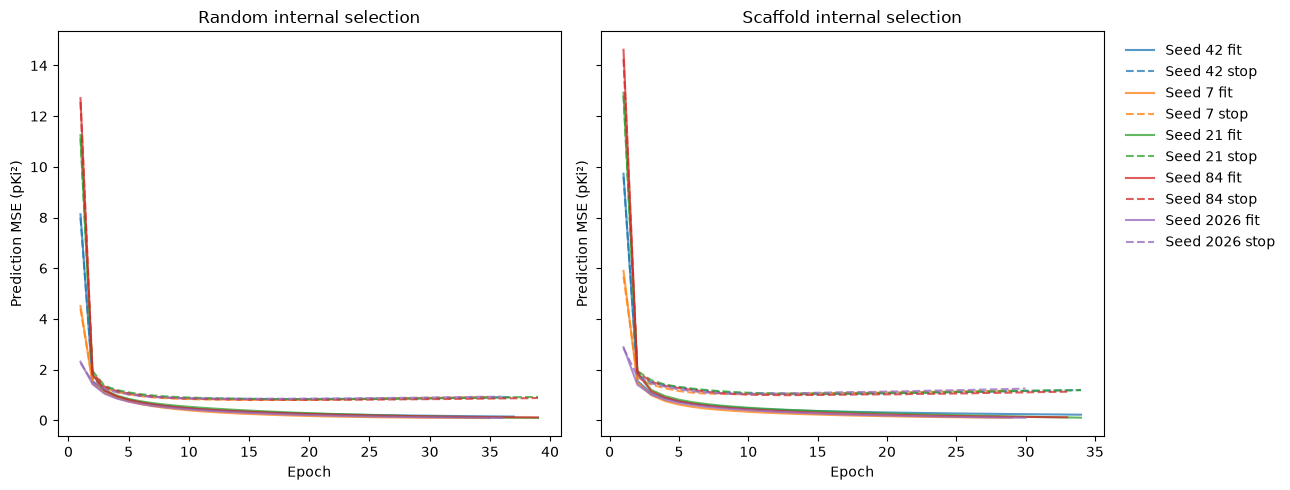

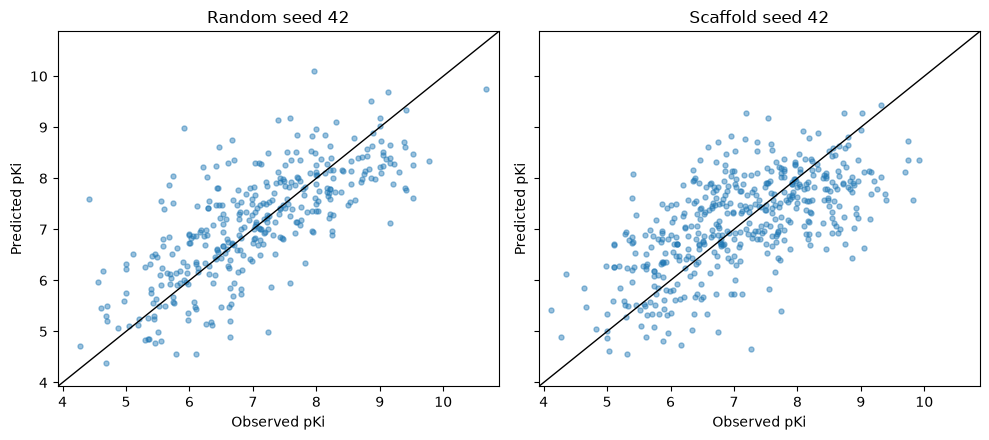

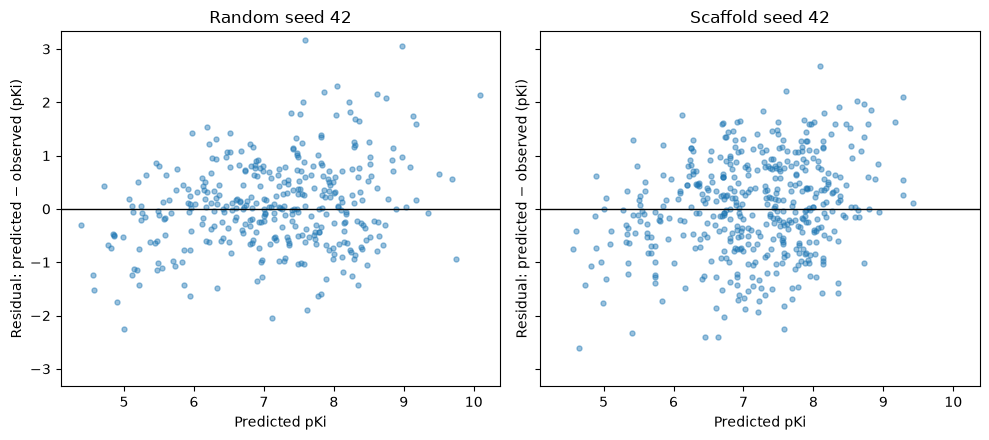

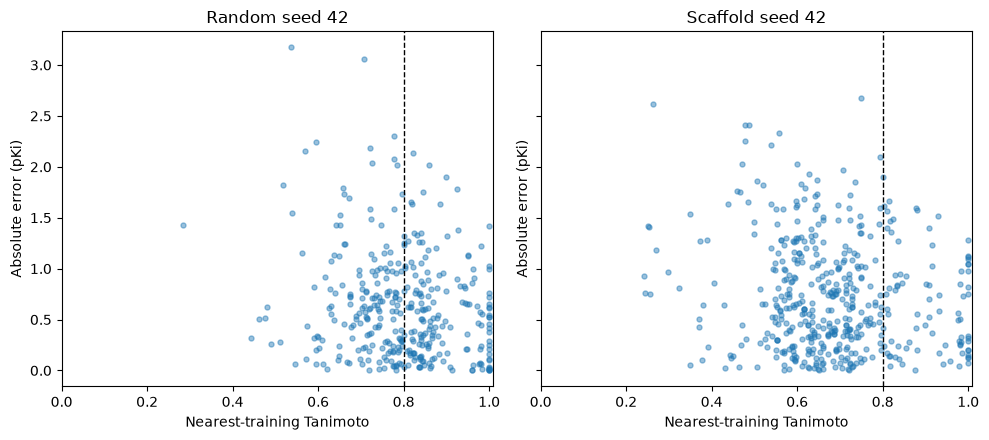

In [10]:
# Save separately until all scientific checks pass, keeping the current result safe.
from mlp_artifacts import new_mlp_candidate, publish_mlp
mlp_folder = new_mlp_candidate(project_root, "baseline")
# Plot paths enter the completion manifest with byte-level hashes.
plot_paths = []

# Each color is one seed; solid is internal fit and dashed is stopping loss.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    for seed in initialization_seeds:
        rows = internal_history.loc[internal_history["split_strategy"].eq(strategy)
                                    & internal_history["initialization_seed"].eq(seed)]
        line, = axis.plot(rows["epoch"], rows["fit_mse_pki2"], alpha=0.75, label=f"Seed {seed} fit")
        axis.plot(rows["epoch"], rows["stopping_mse_pki2"], linestyle="--", alpha=0.75,
                  color=line.get_color(), label=f"Seed {seed} stop")
    axis.set(title=f"{strategy.capitalize()} internal selection", xlabel="Epoch", ylabel="Prediction MSE (pKi²)")
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
fig.tight_layout()
path = mlp_folder / "internal_loss_by_seed.png"
fig.savefig(path, dpi=140, bbox_inches="tight")
plot_paths.append(path)
plt.show()

# Seed 42 was named before results and is never selected by validation score.
representative = joined_validation.loc[joined_validation["initialization_seed"].eq(42)]
lower = float(min(representative["observed_pki"].min(), representative["predicted_pki"].min()) - 0.2)
upper = float(max(representative["observed_pki"].max(), representative["predicted_pki"].max()) + 0.2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    rows = representative.loc[representative["split_strategy"].eq(strategy)]
    axis.scatter(rows["observed_pki"], rows["predicted_pki"], s=13, alpha=0.45)
    axis.plot([lower, upper], [lower, upper], color="black", linewidth=1)
    axis.set(xlim=(lower, upper), ylim=(lower, upper), title=f"{strategy.capitalize()} seed 42",
             xlabel="Observed pKi", ylabel="Predicted pKi")
fig.tight_layout()
path = mlp_folder / "observed_vs_predicted_seed_42.png"
fig.savefig(path, dpi=140)
plot_paths.append(path)
plt.show()

# Signed residuals expose overprediction and underprediction separately.
limit = 1.05 * float(representative["residual"].abs().max())
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    rows = representative.loc[representative["split_strategy"].eq(strategy)]
    axis.scatter(rows["predicted_pki"], rows["residual"], s=13, alpha=0.45)
    axis.axhline(0, color="black", linewidth=1)
    axis.set(ylim=(-limit, limit), title=f"{strategy.capitalize()} seed 42",
             xlabel="Predicted pKi", ylabel="Residual: predicted − observed (pKi)")
fig.tight_layout()
path = mlp_folder / "residuals_seed_42.png"
fig.savefig(path, dpi=140)
plot_paths.append(path)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    rows = representative.loc[representative["split_strategy"].eq(strategy)]
    axis.scatter(rows["maximum_tanimoto"], rows["absolute_error"], s=13, alpha=0.45)
    axis.axvline(cutoff, color="black", linestyle="--", linewidth=1)
    axis.set(xlim=(0, 1.01), title=f"{strategy.capitalize()} seed 42",
             xlabel="Nearest-training Tanimoto", ylabel="Absolute error (pKi)")
fig.tight_layout()
path = mlp_folder / "similarity_error_seed_42.png"
fig.savefig(path, dpi=140)
plot_paths.append(path)
plt.show()


## 11. Save models, reports, and provenance

Save only final full-training models. Internal assignments, histories, selected durations, and fixed cliff pairs remain separate from predictions. The completion manifest is written after readback checks.


In [11]:
# Keep selection, final refit, predictions, and exploratory diagnostics separate.
report_tables = {
    "internal_assignments.csv": internal_assignments,
    "internal_history.csv": internal_history,
    "epoch_selections.csv": selections,
    "full_refit_history.csv": refit_history,
    "predictions.csv": predictions,
    "metrics.csv": metrics,
    "seed_summary.csv": seed_summary,
    "validation_subgroups.csv": subgroups,
    "subgroup_summary.csv": subgroup_summary,
    "cliff_pairs.csv": cliff_pairs,
    "cliff_molecule_groups.csv": cliff_groups,
    "cliff_molecule_group_summary.csv": cliff_group_summary,
    "cliff_results.csv": cliff_results,
    "cliff_summary.csv": cliff_summary,
}
# Files are saved before the independent readback checks below.
for filename, table in report_tables.items():
    table.to_csv(mlp_folder / filename, index=False)
models_path = mlp_folder / "models.joblib.gz"
joblib.dump(models, models_path, compress=("gzip", 3))
# Record exact rules so the tuning notebook can reuse rather than infer them.
configuration = {
    "feature_source": PREP_MANIFEST_REL.as_posix(), "input_bits": feature_width,
    "internal_split": internal_diagnostics, "model_parameters": baseline_parameters,
    "initialization_seeds": initialization_seeds, "maximum_epochs": max_epochs,
    "patience": patience, "epoch_selection": "first strictly lowest internal stopping MSE",
    "full_refit": "fresh model on every outer-training row for selected epochs",
    "representative_plot_seed": 42,
    "cliff_definition": {"scope": "unordered within outer validation", "minimum_tanimoto": cliff_similarity,
                         "minimum_absolute_observed_pki_difference": cliff_pki_gap},
}
# A missing completion manifest still signals an interrupted run.
with (mlp_folder / "configuration.json").open("x", encoding="utf-8") as stream:
    json.dump(configuration, stream, indent=2)
print(f"Saved {len(report_tables)} CSV reports, final models, configuration, and {len(plot_paths)} plots.")


Saved 14 CSV reports, final models, configuration, and 4 plots.


## 12. Verify the saved experiment before marking it complete

Read back membership, models, predictions, metrics, summaries, and cliff arithmetic. Confirm no test keys, frozen upstream hashes, explicit refit epoch counts, and scaffold separation. The manifest records checksums only after these checks pass.


In [12]:
# Reload exports so verification does not merely inspect in-memory tables.
readback = {name: pd.read_csv(mlp_folder / name, keep_default_na=False)
            for name in report_tables}
loaded_models = joblib.load(models_path)
with (mlp_folder / "configuration.json").open(encoding="utf-8") as stream:
    saved_configuration = json.load(stream)
assert saved_configuration["internal_split"] == internal_diagnostics
assert set(loaded_models) == set(MLP_NAMES)
saved_internal = readback["internal_assignments.csv"]
saved_predictions = readback["predictions.csv"]
saved_metrics = readback["metrics.csv"]
saved_selections = readback["epoch_selections.csv"]
saved_refit = readback["full_refit_history.csv"]
saved_history = readback["internal_history.csv"]
saved_cliffs = readback["cliff_pairs.csv"]
assert not saved_internal.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert not saved_predictions.duplicated(["split_strategy", "initialization_seed", "subset", "rdkit_smiles"]).any()
assert set(saved_predictions["subset"]) == {"train", "validation"}
for strategy in MLP_NAMES:
    outer_train = set(structure_keys[split_indices[strategy]["train"]])
    reserved = set(structure_keys[split_indices[strategy]["validation"]]) | set(
        structure_keys[split_indices[strategy]["test"]])
    internal = saved_internal.loc[saved_internal["split_strategy"].eq(strategy)]
    assert set(internal["rdkit_smiles"]) == outer_train
    assert set(internal["rdkit_smiles"]).isdisjoint(reserved)
    assert set(internal["internal_subset"]) == {"fit", "stopping"}
    if strategy == "scaffold":
        fit_groups = set(internal.loc[internal["internal_subset"].eq("fit"), "scaffold"])
        stop_groups = set(internal.loc[internal["internal_subset"].eq("stopping"), "scaffold"])
        assert fit_groups.isdisjoint(stop_groups)
    fit_fp = set(internal.loc[internal["internal_subset"].eq("fit"), "fingerprint_group_id"])
    stop_fp = set(internal.loc[internal["internal_subset"].eq("stopping"), "fingerprint_group_id"])
    assert len(fit_fp & stop_fp) == internal_diagnostics[strategy]["exact_fingerprint_group_overlap"]
    test_keys = set(structure_keys[split_indices[strategy]["test"]])
    assert set(saved_predictions.loc[saved_predictions["split_strategy"].eq(strategy), "rdkit_smiles"]).isdisjoint(test_keys)
    pairs = saved_cliffs.loc[saved_cliffs["split_strategy"].eq(strategy)]
    assert set(pairs["left_rdkit_smiles"]) | set(pairs["right_rdkit_smiles"]) <= set(
        structure_keys[split_indices[strategy]["validation"]])
    assert not (pairs["left_rdkit_smiles"] >= pairs["right_rdkit_smiles"]).any()
    # Independently enumerate all qualifying pairs so a missing saved pair is caught.
    validation_indices = sorted(split_indices[strategy]["validation"],
                                key=lambda index: str(structure_keys[index]))
    bits = [DataStructs.CreateFromBitString(''.join(map(str, X[index]))) for index in validation_indices]
    expected_pairs = set()
    for left_position in range(len(validation_indices) - 1):
        similarities = DataStructs.BulkTanimotoSimilarity(bits[left_position], bits[left_position + 1:])
        for right_position, similarity in enumerate(similarities, start=left_position + 1):
            left_index, right_index = validation_indices[left_position], validation_indices[right_position]
            if similarity >= cliff_similarity and abs(y[left_index] - y[right_index]) >= cliff_pki_gap:
                expected_pairs.add((str(structure_keys[left_index]), str(structure_keys[right_index])))
    assert expected_pairs == set(zip(pairs["left_rdkit_smiles"], pairs["right_rdkit_smiles"]))
    for pair in pairs.itertuples(index=False):
        left_index = np.flatnonzero(structure_keys == pair.left_rdkit_smiles)[0]
        right_index = np.flatnonzero(structure_keys == pair.right_rdkit_smiles)[0]
        left_bits = DataStructs.CreateFromBitString(''.join(map(str, X[left_index])))
        right_bits = DataStructs.CreateFromBitString(''.join(map(str, X[right_index])))
        assert np.isclose(DataStructs.TanimotoSimilarity(left_bits, right_bits), pair.tanimoto, atol=1e-12)
        assert pair.tanimoto >= cliff_similarity and abs(pair.observed_difference_pki) >= cliff_pki_gap
        assert np.isclose(pair.observed_difference_pki, y[left_index] - y[right_index], atol=1e-12)
    for seed in initialization_seeds:
        selection = saved_selections.loc[saved_selections["split_strategy"].eq(strategy)
                                         & saved_selections["initialization_seed"].eq(seed)].iloc[0]
        history = saved_history.loc[saved_history["split_strategy"].eq(strategy)
                                    & saved_history["initialization_seed"].eq(seed)]
        assert list(history["epoch"]) == list(range(1, selection["internal_epochs_run"] + 1))
        assert selection["selected_epoch"] == history.loc[history["stopping_mse_pki2"].idxmin(), "epoch"]
        assert np.isclose(selection["best_stopping_mse_pki2"], history["stopping_mse_pki2"].min(), atol=1e-12)
        refit = saved_refit.loc[saved_refit["split_strategy"].eq(strategy)
                                & saved_refit["initialization_seed"].eq(seed)]
        assert list(refit["epoch"]) == list(range(1, selection["selected_epoch"] + 1))
        assert len(refit) == selection["full_refit_epochs_run"] == selection["selected_epoch"]
        assert refit["training_structures"].eq(len(outer_train)).all()
        model = loaded_models[strategy][seed]
        assert isinstance(model, MLPRegressor)
        assert model.random_state == seed
        assert sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_) == parameter_count
        for subset in ("train", "validation"):
            indices = split_indices[strategy][subset]
            rows = saved_predictions.loc[saved_predictions["split_strategy"].eq(strategy)
                                         & saved_predictions["initialization_seed"].eq(seed)
                                         & saved_predictions["subset"].eq(subset)].set_index("rdkit_smiles")
            assert set(rows.index) == set(structure_keys[indices])
            rows = rows.loc[structure_keys[indices]]
            actual = y[indices]
            predicted = model.predict(X_float[indices])
            np.testing.assert_allclose(rows["observed_pki"], actual, atol=1e-12)
            np.testing.assert_allclose(rows["predicted_pki"], predicted, rtol=0, atol=1e-10)
            errors = predicted - actual
            np.testing.assert_allclose(rows["residual"], errors, atol=1e-12)
            np.testing.assert_allclose(rows["absolute_error"], np.abs(errors), atol=1e-12)
            metric = saved_metrics.loc[saved_metrics["split_strategy"].eq(strategy)
                                       & saved_metrics["initialization_seed"].eq(seed)
                                       & saved_metrics["subset"].eq(subset)].iloc[0]
            expected = metric_record(actual, predicted)
            assert metric["n_structures"] == expected["n_structures"]
            for field in ("mae_pki", "rmse_pki", "r2"):
                assert np.isclose(metric[field], expected[field], atol=1e-12)

# Recompute model-level summaries and cliff pair arithmetic from saved predictions.
for row in readback["seed_summary.csv"].itertuples(index=False):
    group = saved_metrics.loc[saved_metrics["split_strategy"].eq(row.split_strategy)
                              & saved_metrics["subset"].eq(row.subset)]
    assert len(group) == len(initialization_seeds)
    for field in ("mae_pki", "rmse_pki", "r2"):
        assert np.isclose(getattr(row, f"{field}_mean"), group[field].mean(), atol=1e-12)
        assert np.isclose(getattr(row, f"{field}_sample_sd"), group[field].std(ddof=1), atol=1e-12)
for row in readback["validation_subgroups.csv"].itertuples(index=False):
    group = joined_validation.loc[joined_validation["split_strategy"].eq(row.split_strategy)
                                  & joined_validation["initialization_seed"].eq(row.initialization_seed)]
    if row.grouping == "exact_training_fingerprint":
        mask = group["exact_training_fingerprint_match"] if row.group == "exact_match" else ~group["exact_training_fingerprint_match"]
    else:
        mask = group["maximum_tanimoto"].lt(cutoff) if row.group == "below_0.80" else group["maximum_tanimoto"].ge(cutoff)
    selected = group.loc[mask]
    assert row.n_structures == len(selected)
    if len(selected):
        expected = metric_record(selected["observed_pki"].to_numpy(), selected["predicted_pki"].to_numpy())
        assert np.isclose(row.mae_pki, expected["mae_pki"], atol=1e-12)
        assert np.isclose(row.rmse_pki, expected["rmse_pki"], atol=1e-12)
for row in readback["subgroup_summary.csv"].itertuples(index=False):
    group = readback["validation_subgroups.csv"].loc[
        readback["validation_subgroups.csv"]["split_strategy"].eq(row.split_strategy)
        & readback["validation_subgroups.csv"]["grouping"].eq(row.grouping)
        & readback["validation_subgroups.csv"]["group"].eq(row.group)]
    assert len(group) == len(initialization_seeds) and group["n_structures"].eq(row.n_structures).all()
    if row.n_structures:
        assert np.isclose(row.mae_pki_mean, group["mae_pki"].mean(), atol=1e-12)
        assert np.isclose(row.mae_pki_sample_sd, group["mae_pki"].std(ddof=1), atol=1e-12)
for row in readback["cliff_results.csv"].itertuples(index=False):
    pairs = saved_cliffs.loc[saved_cliffs["split_strategy"].eq(row.split_strategy)]
    predictions_for_seed = saved_predictions.loc[saved_predictions["split_strategy"].eq(row.split_strategy)
                                                 & saved_predictions["initialization_seed"].eq(row.initialization_seed)
                                                 & saved_predictions["subset"].eq("validation")].set_index("rdkit_smiles")
    assert row.n_pairs == len(pairs)
    if len(pairs):
        predicted_difference = (predictions_for_seed.loc[pairs["left_rdkit_smiles"], "predicted_pki"].to_numpy()
                                - predictions_for_seed.loc[pairs["right_rdkit_smiles"], "predicted_pki"].to_numpy())
        observed_difference = pairs["observed_difference_pki"].to_numpy()
        assert np.isclose(row.pair_difference_mae_pki, np.mean(np.abs(predicted_difference - observed_difference)), atol=1e-12)
        assert row.predicted_ties == np.count_nonzero(predicted_difference == 0)
        assert np.isclose(row.correct_direction_fraction,
                          np.mean(np.sign(predicted_difference) == np.sign(observed_difference)), atol=1e-12)
for row in readback["cliff_molecule_groups.csv"].itertuples(index=False):
    pairs = saved_cliffs.loc[saved_cliffs["split_strategy"].eq(row.split_strategy)]
    participants = set(pairs["left_rdkit_smiles"]) | set(pairs["right_rdkit_smiles"])
    pred = saved_predictions.loc[saved_predictions["split_strategy"].eq(row.split_strategy)
                                 & saved_predictions["initialization_seed"].eq(row.initialization_seed)
                                 & saved_predictions["subset"].eq("validation")]
    mask = pred["rdkit_smiles"].isin(participants)
    selected = pred.loc[mask if row.group == "cliff_participant" else ~mask]
    assert row.n_structures == len(selected)
    if len(selected):
        expected = metric_record(selected["observed_pki"].to_numpy(), selected["predicted_pki"].to_numpy())
        assert np.isclose(row.mae_pki, expected["mae_pki"], atol=1e-12)
        assert np.isclose(row.rmse_pki, expected["rmse_pki"], atol=1e-12)
for row in readback["cliff_summary.csv"].itertuples(index=False):
    group = readback["cliff_results.csv"].loc[readback["cliff_results.csv"]["split_strategy"].eq(row.split_strategy)]
    assert len(group) == len(initialization_seeds) and group["n_pairs"].eq(row.n_pairs).all()
    if row.n_pairs:
        assert np.isclose(row.pair_difference_mae_pki_mean, group["pair_difference_mae_pki"].mean(), atol=1e-12)
        assert np.isclose(row.correct_direction_fraction_mean, group["correct_direction_fraction"].mean(), atol=1e-12)
for row in readback["cliff_molecule_group_summary.csv"].itertuples(index=False):
    group = readback["cliff_molecule_groups.csv"].loc[
        readback["cliff_molecule_groups.csv"]["split_strategy"].eq(row.split_strategy)
        & readback["cliff_molecule_groups.csv"]["group"].eq(row.group)]
    assert len(group) == len(initialization_seeds) and group["n_structures"].eq(row.n_structures).all()
    if row.n_structures:
        assert np.isclose(row.mae_pki_mean, group["mae_pki"].mean(), atol=1e-12)
        assert np.isclose(row.rmse_pki_mean, group["rmse_pki"].mean(), atol=1e-12)

assert sha256_file(prep_manifest_path) == source_manifest_hash
for filename, path in artifact_paths.items():
    assert sha256_file(path) == prep_manifest["artifact_sha256"][(prep_folder_rel / filename).as_posix()]
output_paths = [mlp_folder / name for name in report_tables]
output_paths += [models_path, mlp_folder / "configuration.json", *plot_paths]
manifest = {
    "stage": "mlp_baseline_training_and_evaluation", "notebook": "notebooks/08_mlp_baseline.ipynb",
    "run_started_at_utc": run_started_at_utc, "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "output_folder": mlp_folder.relative_to(project_root).as_posix(),
    "source_preparation_manifest": PREP_MANIFEST_REL.as_posix(),
    "source_preparation_manifest_sha256": source_manifest_hash,
    "source_artifact_sha256": {path.relative_to(project_root).as_posix(): sha256_file(path)
                               for path in artifact_paths.values()},
    "configuration": configuration,
    "counts": {"final_models": sum(len(group) for group in loaded_models.values()),
               "internal_assignment_rows": len(saved_internal), "prediction_rows": len(saved_predictions),
               "metric_rows": len(saved_metrics), "cliff_pairs": len(saved_cliffs)},
    "output_sha256": {path.relative_to(project_root).as_posix(): sha256_file(path) for path in output_paths},
    "verification": {"frozen_inputs": True, "internal_membership_and_scaffolds": True,
                     "training_only_epoch_selection": True, "explicit_full_refit_epochs": True,
                     "reloaded_model_predictions": True, "metrics_and_seed_summaries": True,
                     "similarity_subgroups": True, "cliff_pairs_and_difference_arithmetic": True,
                     "test_excluded": True},
    "fitting_performed": True, "tuning_performed": False,
    "outer_validation_used_for_epoch_selection": False,
    "test_predictions_performed": False, "test_evaluation_performed": False,
    "software_versions": {**installed_versions, "matplotlib": matplotlib.__version__},
}
with (mlp_folder / "manifest.json").open("x", encoding="utf-8") as stream:
    json.dump(manifest, stream, indent=2)
# Publish one accepted execution and its reader-friendly summary workbook.
# A baseline replacement also clears tuning that depends on the older baseline.
mlp_folder = publish_mlp(project_root, mlp_folder, "baseline")
print(f"Verified {manifest['counts']['final_models']} fresh full-training models, "
      f"{len(saved_predictions):,} predictions, {len(saved_cliffs):,} frozen cliff pairs, and all output hashes.")
print(f"Completed corrected baseline: {mlp_folder.relative_to(project_root).as_posix()}")


Accepted baseline. Previous dependent tuning was cleared; run notebook 09 to refresh it.
Verified 10 fresh full-training models, 32,285 predictions, 121 frozen cliff pairs, and all output hashes.
Completed corrected baseline: provenance/models/multilayer_perceptron/baseline


## Stopping point

These are corrected **development-validation** baseline results. Initialization spread is reported across five fixed seeds on each fixed split. Cliff findings are exploratory and do not drive model choice. The separate tuning notebook will reuse the exact internal membership and cliff-pair files; the reserved test sets remain untouched.


## Refresh the project reference
After this stage passes its checks, update the model comparison and project file guide. The data provenance workbook is regenerated from the current data. Existing model results remain labeled with the dataset that produced them.


In [13]:
# Verify saved evidence and refresh the Markdown references and the data provenance workbook.
from build_project_reference import build_reference
build_reference()


{
  "checksum_references": 153,
  "recomputed_metric_rows": 56,
  "active_notebooks": 10,
  "model_comparison_rows": 20,
  "current_pipeline": {
    "acquisition": "provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json",
    "selection": "provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json",
    "curation": "provenance/curation/manifest.json",
    "preparation": "provenance/preparation/manifest.json"
  },
  "reports_written": true,
  "presentation_workbook": "preserved unchanged"
}


{'checksum_references': 153,
 'recomputed_metric_rows': 56,
 'active_notebooks': 10,
 'model_comparison_rows': 20,
 'current_pipeline': {'acquisition': 'provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json',
  'selection': 'provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json',
  'curation': 'provenance/curation/manifest.json',
  'preparation': 'provenance/preparation/manifest.json'},
 'reports_written': True,
 'presentation_workbook': 'preserved unchanged'}